# HTAN cohort composition

Rebuilds the figures from `plotting/archive/` against `pdacagviz`, replacing four
hand-maintained colour dictionaries with one palette and the per-script
`figsize=(9, ...)` guesses with mode-aware sizing.

Two things differ from the originals beyond styling:

- **The data is in the repository.** The archived scripts read
  `~/OneDrive - University of Maryland School of Medicine/HTANDATA/...`, which
  only existed on one machine. `assignmentsummary_HTAN_singlecell.csv` is
  checked in and carries the same counts.
- **Cell-type names come from the model.** The CSV says `Pattern2` and
  `CD8_T_cytotoxic`; the simulations, palettes and figures say `epithelial` and
  `CD8_Tcell`. `scripts/htan_cohort.py` applies the mapping
  `run_htan_singlecell_tme_geometries.jl` used to seed the runs, so a figure
  here is labelled the same way as the simulation it describes.

Its totals agree with `derived/all_initial.h5ad` to the cell: 148,939.

In [ ]:
# pdacagviz is not installed -- `pip install -e .` is deferred -- so the
# repository root has to be on the path for `import pdacagviz` to resolve.
# This line is the cost of that decision, and the signal to revisit it if a
# second notebook needs the same thing.
import sys

sys.path.insert(0, "..")

import pandas as pd
import pdacagviz
from scripts.htan_cohort import load

pdacagviz.configure(mode="article")
pdacagviz.settings.palette = "atlas"  # HTAN input data, not simulation output

cohort = load()
cohort.head()

,sample_id,patient_id,cell_type,count
0,HT056P1_S1PA,HT056,CAF,393
1,HT056P1_S1PB,HT056,CAF,752
2,HT056P1_S1R1,HT056,CAF,796
3,HT060P1_S1PA,HT060,CAF,4225
4,HT060P1_S1PB,HT060,CAF,2749


## 1 · Pooled cell counts

After `plot_agent_counts.py`. That script drew a grey bar for any type missing
from its 46-entry dictionary; `strict=True` raises instead, which is how the
four absent `epithelial_mesenchymal` entries were found.

[PosixPath('/autofs/projects-t3/fertig_pdacagmodel/htan_wellmixed/PDACAntigenPresentationABMs/figures/cohort_counts_pooled.png'),
 PosixPath('/autofs/projects-t3/fertig_pdacagmodel/htan_wellmixed/PDACAntigenPresentationABMs/figures/cohort_counts_pooled.pdf')]

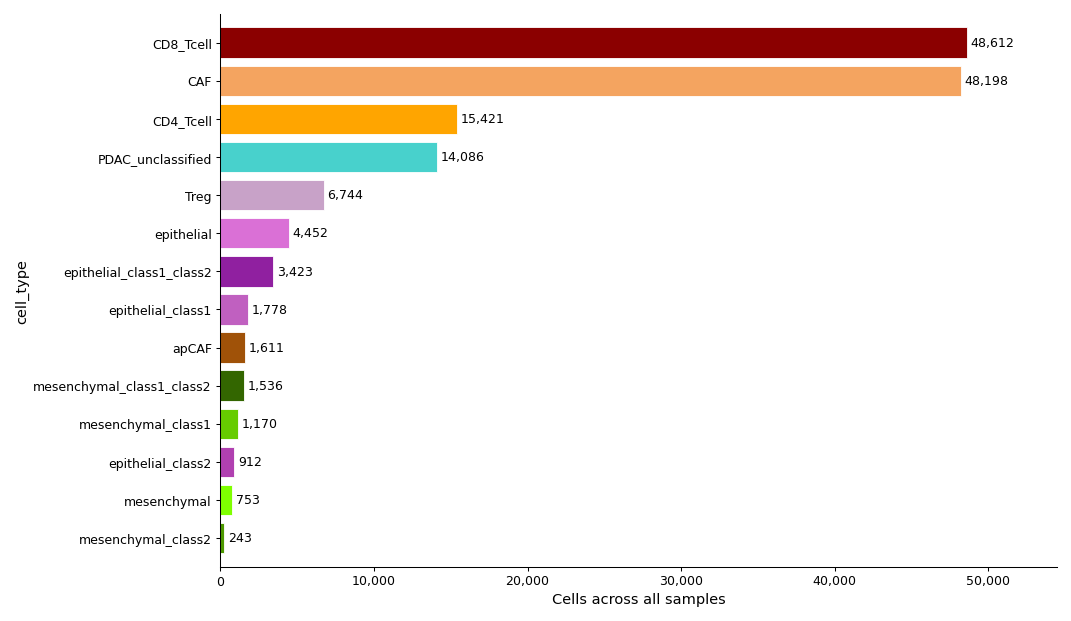

In [ ]:
pooled = cohort.groupby("cell_type", as_index=False)["count"].sum()

ax = pdacagviz.bar(pooled, x="count", y="cell_type", xlabel="Cells across all samples")
pdacagviz.save(ax, "cohort_counts_pooled")

## 2 · Composition per sample

After `plot_agent_counts_per_sample.py`, which computed its figure height as
`max(6, n*0.32 + 1.5)` for a 9-inch-wide screen figure. `figsize` derives it
from the row count and the mode's type scale instead.

[PosixPath('/autofs/projects-t3/fertig_pdacagmodel/htan_wellmixed/PDACAntigenPresentationABMs/figures/cohort_composition_by_sample.png'),
 PosixPath('/autofs/projects-t3/fertig_pdacagmodel/htan_wellmixed/PDACAntigenPresentationABMs/figures/cohort_composition_by_sample.pdf')]

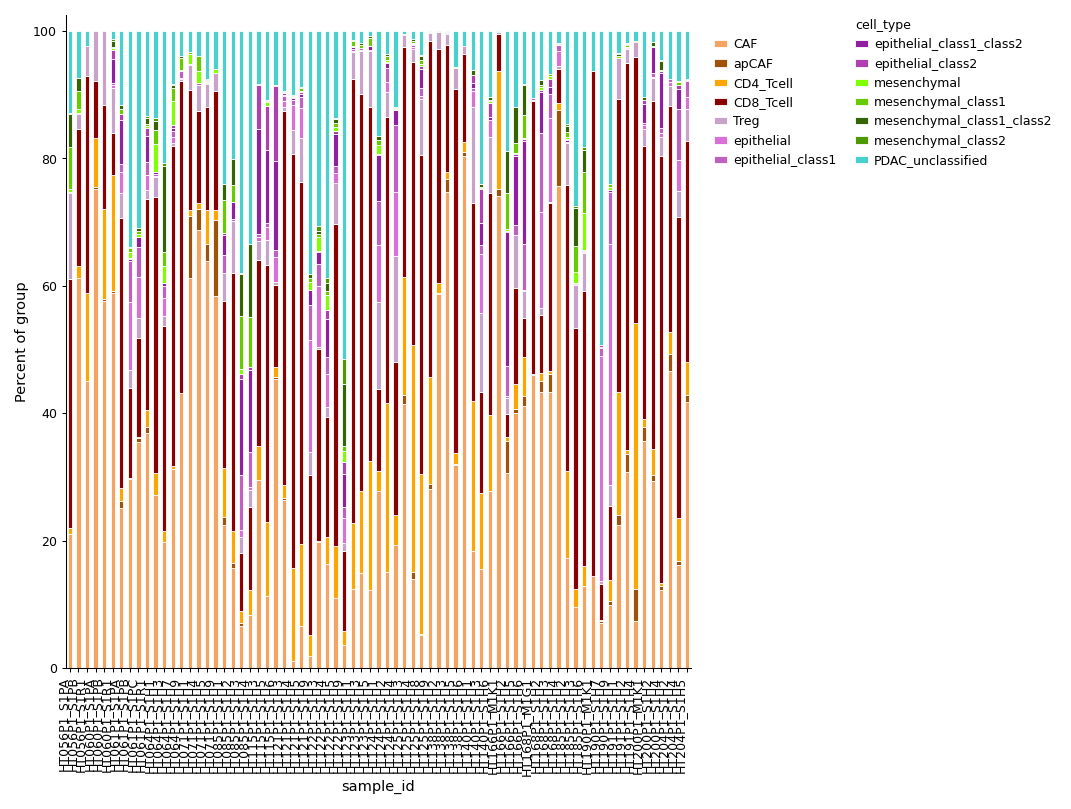

In [ ]:
ax = pdacagviz.composition(
    cohort,
    x="sample_id",
    hue="cell_type",
    y="count",
    kind="stacked",
    width="full",
    x_rotation=90,
    legend_ncols=2,
)
pdacagviz.save(ax, "cohort_composition_by_sample")

## 3 · Antigen-presenting tumour fraction, by patient

The class-1/class-2 columns say which tumour cells present antigen. Grouping
by patient rather than sample keeps the axis readable at 21 categories rather
than 73.

[PosixPath('/autofs/projects-t3/fertig_pdacagmodel/htan_wellmixed/PDACAntigenPresentationABMs/figures/antigen_presenting_by_patient.png'),
 PosixPath('/autofs/projects-t3/fertig_pdacagmodel/htan_wellmixed/PDACAntigenPresentationABMs/figures/antigen_presenting_by_patient.pdf')]

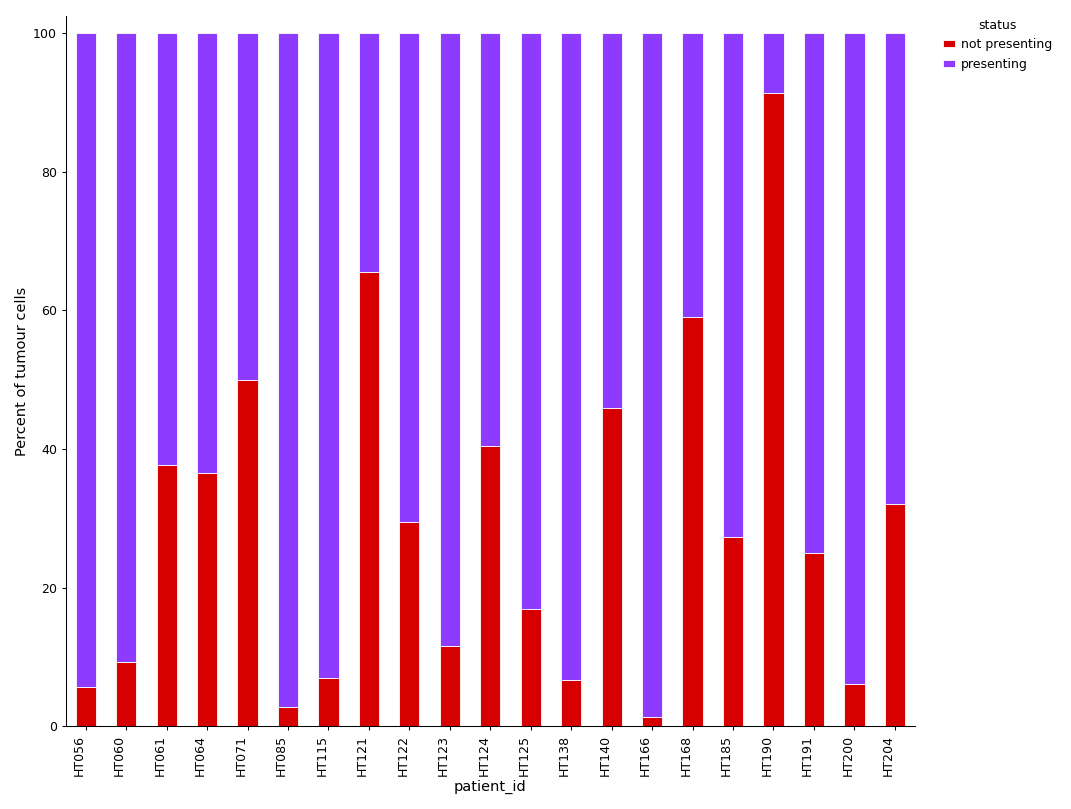

In [ ]:
tumour = cohort[cohort.cell_type.str.startswith(("epithelial", "mesenchymal"))].copy()
tumour["presenting"] = tumour.cell_type.str.contains("class")

by_patient = tumour.groupby(["patient_id", "presenting"], as_index=False)["count"].sum()
by_patient["status"] = by_patient.presenting.map(
    {True: "presenting", False: "not presenting"}
)

ax = pdacagviz.composition(
    by_patient,
    x="patient_id",
    hue="status",
    y="count",
    kind="stacked",
    x_rotation=90,
    ylabel="Percent of tumour cells",
)
pdacagviz.save(ax, "antigen_presenting_by_patient")

## 4 · apCAF against T cells

After `plot_apcaf_vs_tcells.py`, which fixed `s=60` regardless of figure size.
`marker_size` scales with the point count and the drawing area, so the same
call works in article and poster mode.

[PosixPath('/autofs/projects-t3/fertig_pdacagmodel/htan_wellmixed/PDACAntigenPresentationABMs/figures/apcaf_vs_tcells.png'),
 PosixPath('/autofs/projects-t3/fertig_pdacagmodel/htan_wellmixed/PDACAntigenPresentationABMs/figures/apcaf_vs_tcells.pdf')]

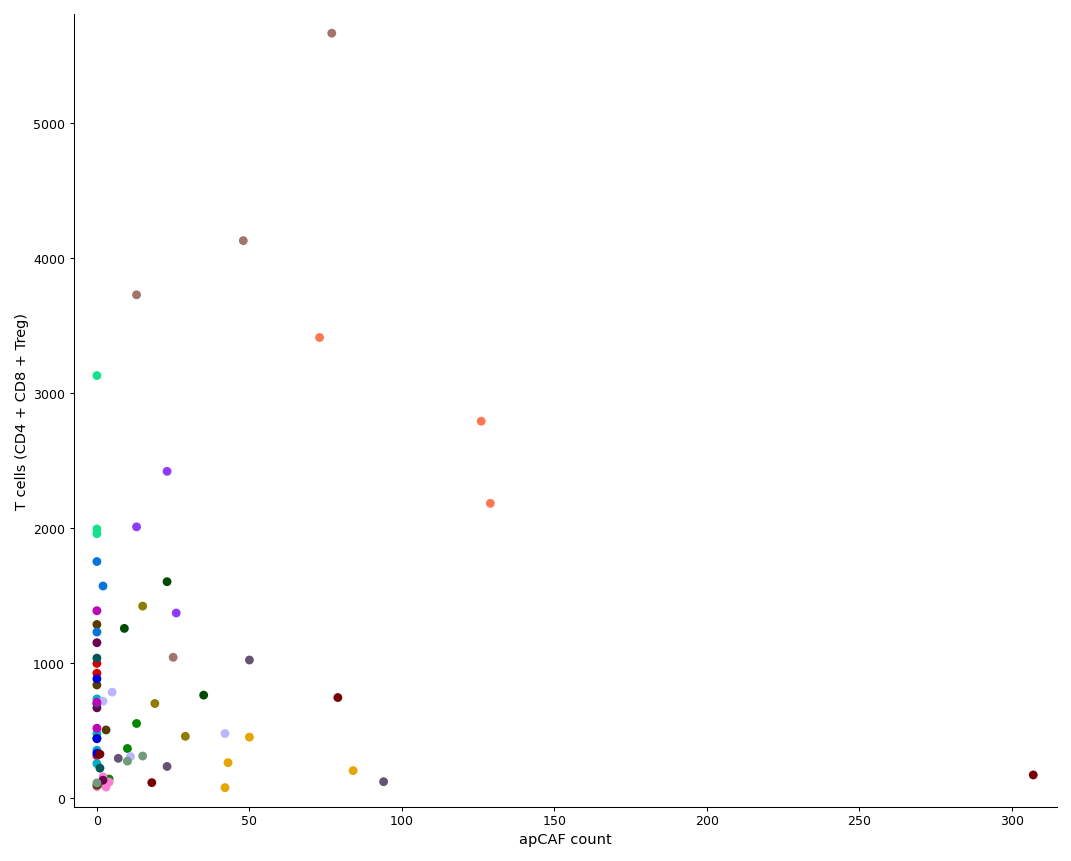

In [ ]:
wide = load(long=False)
wide["T_cells"] = wide[["CD4_Tcell", "CD8_Tcell", "Treg"]].sum(axis=1)

ax = pdacagviz.relationship(
    wide,
    x="apCAF",
    y="T_cells",
    hue="patient_id",
    kind="scatter",
    ratio=0.8,
    xlabel="apCAF count",
    ylabel="T cells (CD4 + CD8 + Treg)",
)
pdacagviz.save(ax, "apcaf_vs_tcells")

## 5 · The same figure, poster mode

The point of the mode switch: one scoped block, no other change. Type, line
weights, tick geometry and physical size all move together.

poster: [14.    8.38] in


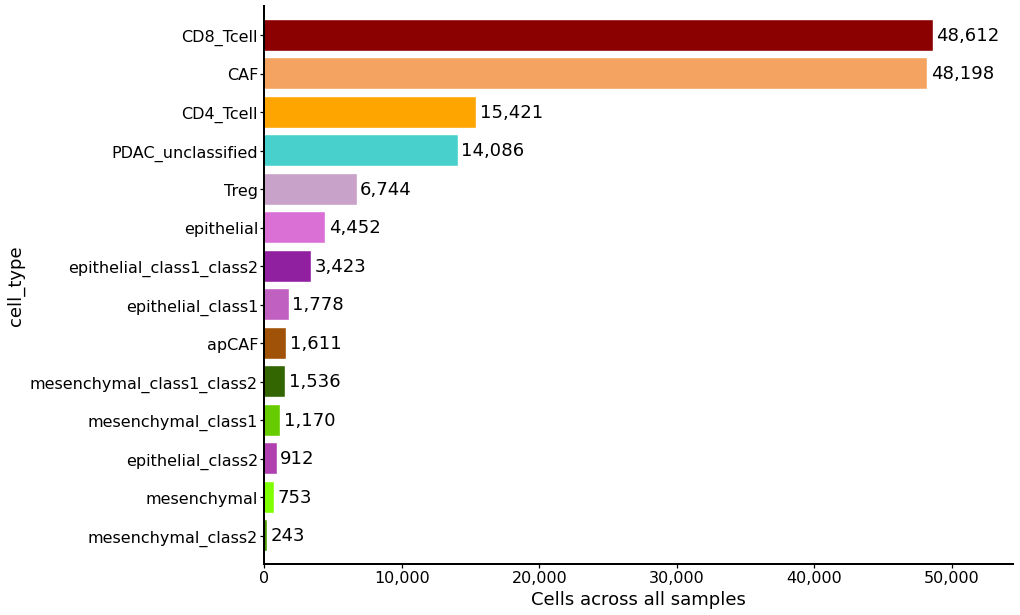

In [ ]:
with pdacagviz.settings.using(mode="poster"):
    ax = pdacagviz.bar(
        pooled, x="count", y="cell_type", xlabel="Cells across all samples"
    )
    pdacagviz.save(ax, "cohort_counts_pooled_poster")
    print(f"poster: {ax.figure.get_size_inches().round(2)} in")